Import data and libraries

In [1]:
#k-map clustering

#import all needed
import numpy as np
import matplotlib.pyplot as plt
#get data
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
print(wine.feature_names)
data = pd.DataFrame(wine.data, columns=wine.feature_names)
data['target'] = wine.target
X = data[['malic_acid', 'proline']]
all_data=X.to_numpy()
all_data=all_data.T
print(all_data.shape)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
(2, 178)


Initialise the k-means clustering

In [2]:
#create number of groups 
labels = np.zeros(all_data.shape[1], dtype=int)

k = 3

# pick the centroids at random from the data
centroids = np.zeros((2, k))
rand_point_indices = np.random.choice(all_data.shape[1], k, replace=False)
for i in range(k):
    centroids[:, i] = all_data[:, rand_point_indices[i]]
    print(f'centroid {i} is at {centroids[:, i]}')

# first, make some random colours and markers (have tried to make this colourblind friendly!)
colours = plt.cm.get_cmap('hsv', k + 1)
dullcolours = []
for i in range(k):
    colour = colours(i)
    dullcolour = (max(colour[0], 0.6), max(colour[1], 0.6), max(colour[2], 0.6), 1)
    dullcolours.append(dullcolour)
    
markers = "x^1spP*D|_>38Hd"

centroid 0 is at [  1.41 428.  ]
centroid 1 is at [   1.73 1150.  ]
centroid 2 is at [  2.96 590.  ]


C:\Users\HABHo\AppData\Local\Temp\ipykernel_10720\3497761501.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = plt.cm.get_cmap('hsv', k + 1)


Plot initial data and random centroids

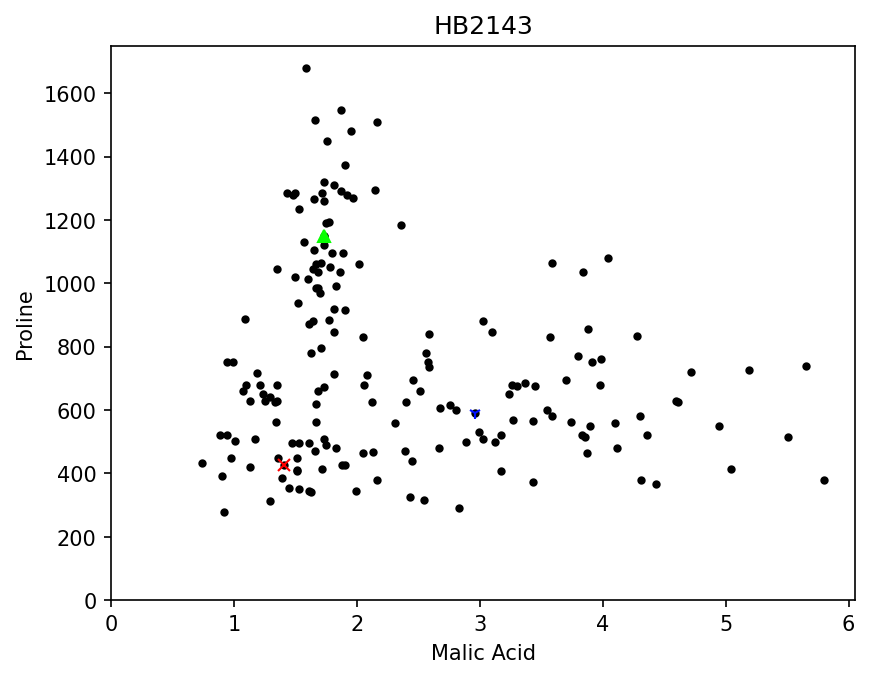

In [3]:
# now plot the original data in black quite small
fig = plt.figure(dpi=150)
plt.plot(all_data[0,:], all_data[1,:], 'ok', ms=3)
plt.xlabel("Malic Acid")
plt.ylabel("Proline")
plt.title("HB2143")

# now plot the centroids on top in random colours a bit bigger
for i in range(k):
    plt.plot(centroids[0, i], centroids[1, i], marker=markers[i % len(markers)], c=colours(i))

a = plt.axis()
plt.axis([0, a[1], 0, a[3]])
plt.show()

Function to do first round of K-means

In [4]:
# round one of the k-means algorithm

def k_means_labels(all_data, centroids, labels):
    num_changed = 0
    k = centroids.shape[1]
    
    for data_index in range(all_data.shape[1]):
        # find the distance from this point to each centroid
        this_point = all_data[:, data_index]

        min_dist = float("inf")
        closest_centroid = -1
        for centroid_index in range(k):
            this_centroid = centroids[:, centroid_index]

#             squared distance, no need to square root since we're just looking for smallest
            distance = np.power(this_point[0] - this_centroid[0], 2) + \
                       np.power(this_point[1] - this_centroid[1], 2)

            if distance < min_dist:
                min_dist = distance
                closest_centroid = centroid_index

        if labels[data_index] != closest_centroid:
            labels[data_index] = closest_centroid
            num_changed += 1

    return num_changed

Plot the first dataset

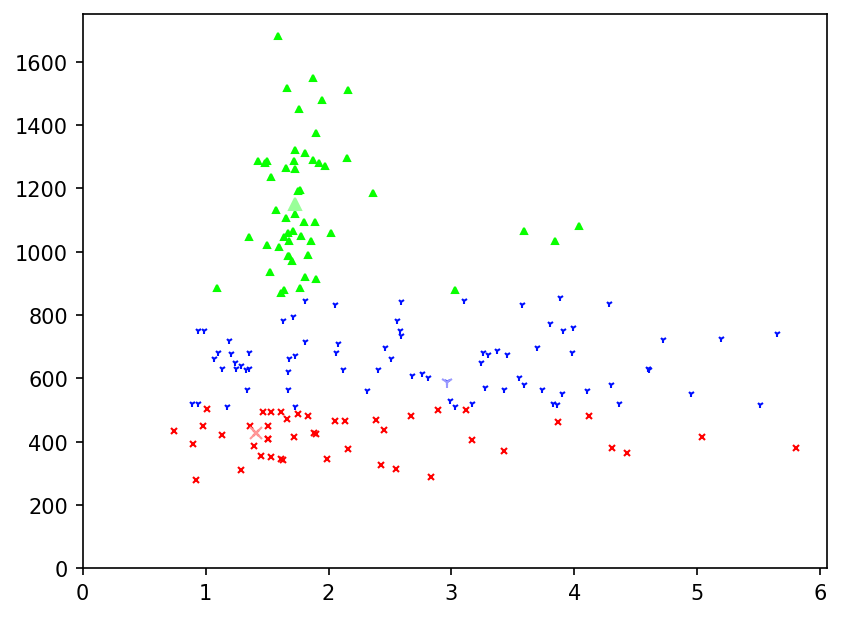

In [5]:
k_means_labels(all_data, centroids, labels)


# plot the data points again, coloured by label with corresponding marker
fig = plt.figure(dpi=150)
for i in range(k):
    plt.plot(all_data[0, labels==i], all_data[1, labels==i], linestyle="None", marker=markers[i % len(markers)], c=colours(i), ms=3)
    plt.plot(centroids[0, i], centroids[1, i], marker=markers[i % len(markers)], c=dullcolours[i])

a = plt.axis()

plt.axis([0, a[1], 0, a[3]]);

Update the centroids and re-plot

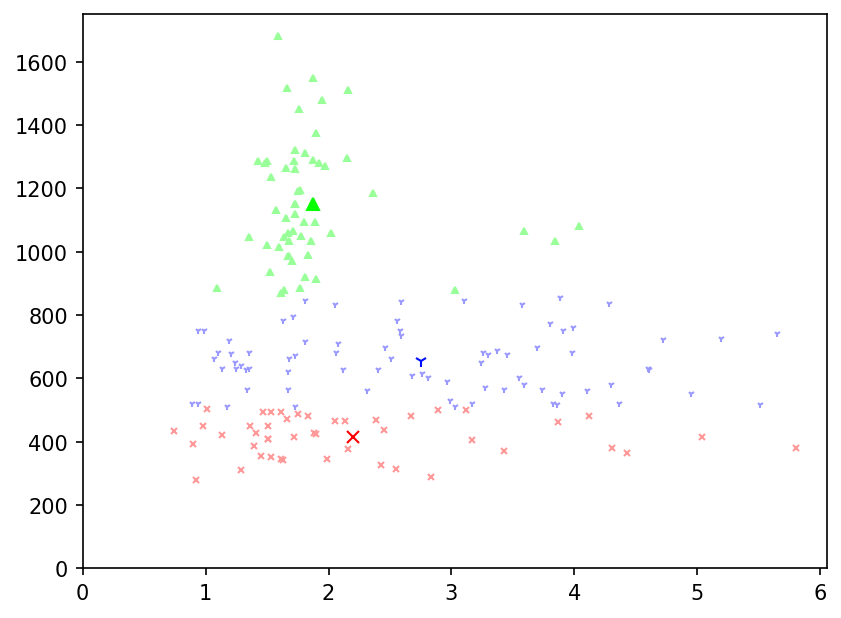

In [6]:
# now update the centroids
def k_means_centroids(all_data, centroids, labels):
    for i in range(centroids.shape[1]):
        centroids[:, i] = np.mean(all_data[:, labels == i], axis=1)
    
k_means_centroids(all_data, centroids, labels)

# plot the new centroids, coloured by label with corresponding marker
fig = plt.figure(dpi=150)
for i in range(k):
    plt.plot(all_data[0, labels==i], all_data[1, labels==i], linestyle="None", marker=markers[i % len(markers)], c=dullcolours[i], ms=3)
    plt.plot(centroids[0, i], centroids[1, i], marker=markers[i % len(markers)], c=colours(i))

a = plt.axis()
plt.axis([0, a[1], 0, a[3]]);

Loop between plotting points, then updating the centroids

Recalculate means:


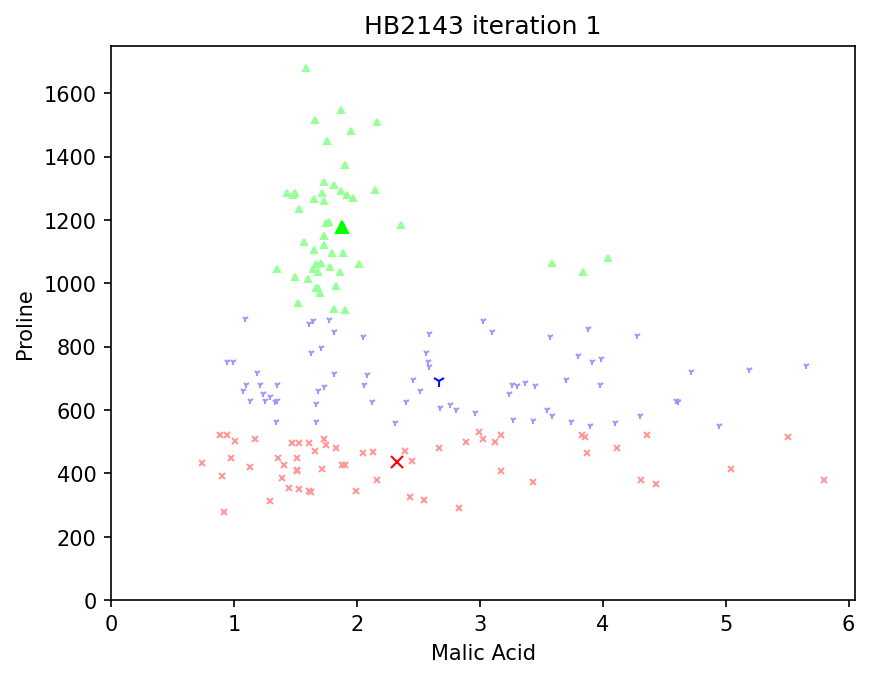

Recalculate means:


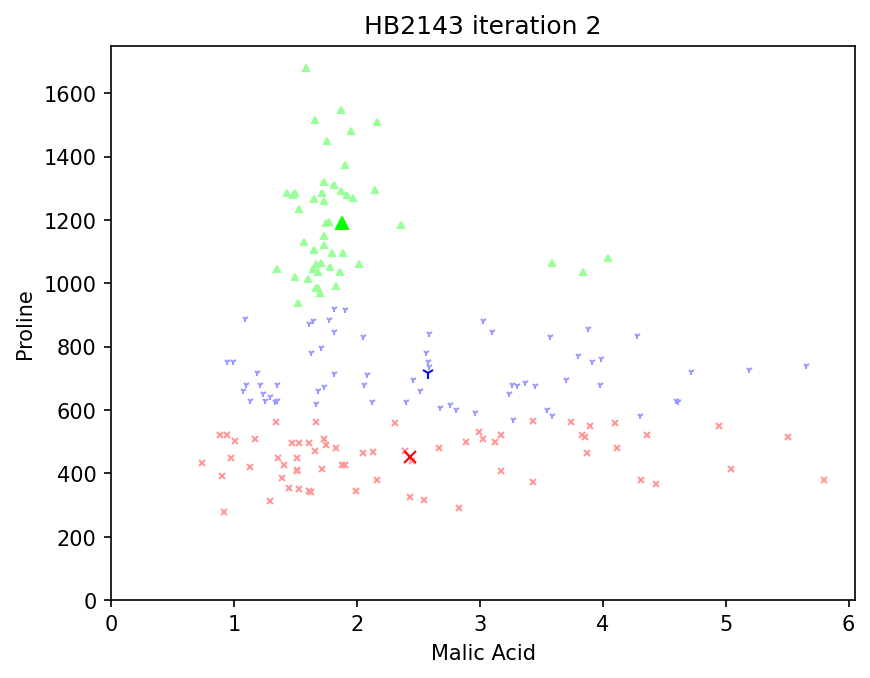

Recalculate means:


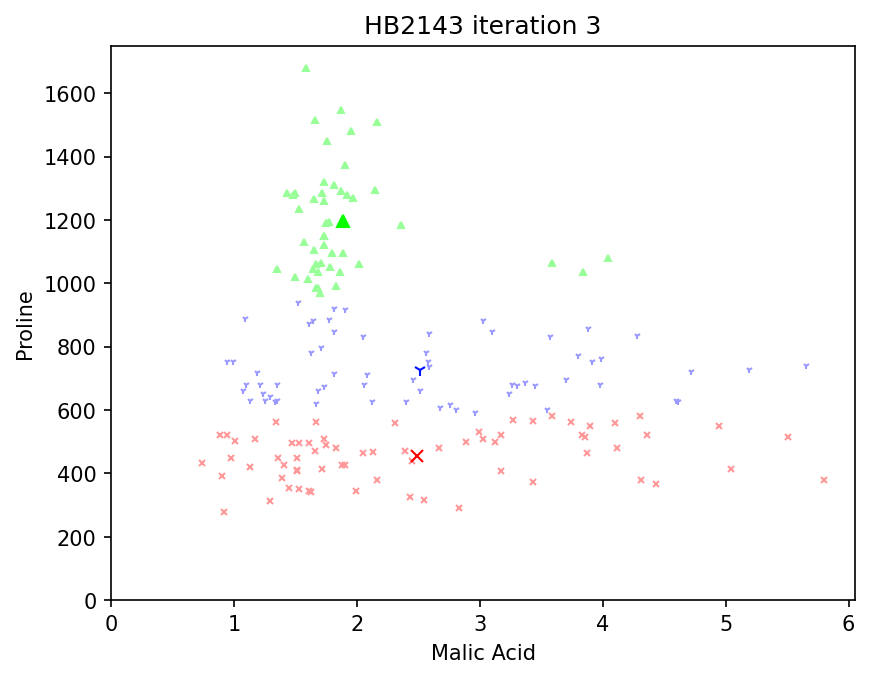

Recalculate means:


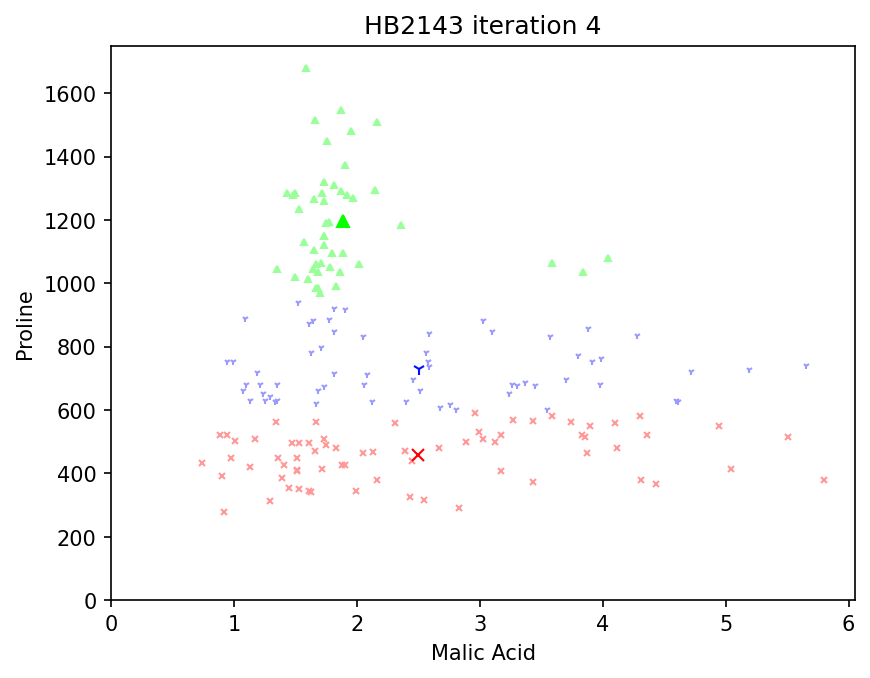

No points changed!
Total 5 iterations


<Figure size 960x720 with 0 Axes>

In [7]:
def k_means_loop(all_data, centroids, labels, plot=True):
    iterations = 0
    while True:
        iterations += 1
        num_changed = k_means_labels(all_data, centroids, labels)
        
        
        if num_changed == 0:
            if plot: print("No points changed!")
            break
            
            
        k_means_centroids(all_data, centroids, labels)
        
        if plot:
            print("Recalculate means:")
            fig = plt.figure(dpi=150)
            for i in range(k):
                plt.plot(all_data[0, labels==i], all_data[1, labels==i], linestyle="None", marker=markers[i % len(markers)], c=dullcolours[i], ms=3)
                plt.plot(centroids[0, i], centroids[1, i], marker=markers[i % len(markers)], c=colours(i))

                a = plt.axis()

            plt.axis([0, a[1], 0, a[3]])
            plt.xlabel("Malic Acid")
            plt.ylabel("Proline")
            plt.title(f"HB2143 iteration {iterations}")
            plt.show()


    return iterations


iterations = k_means_loop(all_data, centroids, labels)
print(f"Total {iterations} iterations")
fig = plt.figure(dpi=150)

Final iteration

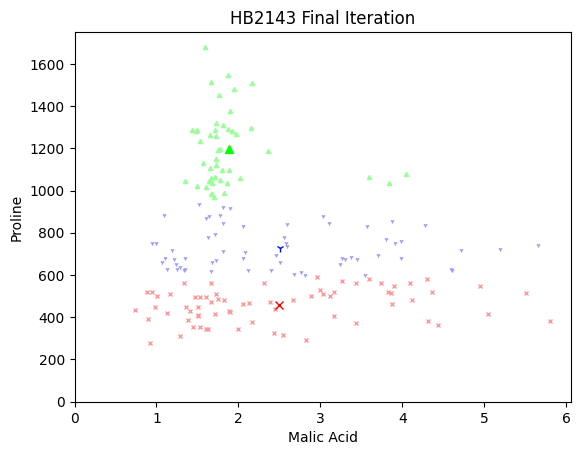

In [8]:
for i in range(k):
    plt.plot(all_data[0, labels==i], all_data[1, labels==i], linestyle="None", marker=markers[i % len(markers)], c=dullcolours[i], ms=3)
    plt.plot(centroids[0, i], centroids[1, i], marker=markers[i % len(markers)], c=colours(i))

    a = plt.axis()

plt.axis([0, a[1], 0, a[3]])
plt.xlabel("Malic Acid")
plt.ylabel("Proline")
plt.title("HB2143 Final Iteration")
plt.show()

In [9]:
from sklearn.metrics import silhouette_score

# Convert data back to shape (n_samples, 2) from (2, n_samples)
X_clustered = all_data.T  # shape = (n_samples, 2)

# Compute silhouette score
score = silhouette_score(X_clustered, labels)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.581
